# Stationarity and Non-stationarity

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [91]:
np.random.seed(42)
n = 365

In [92]:
# Stationary Series: White noise around a constant mean
stationary = pd.Series(np.random.normal(loc=0, scale=1, size=n), index=pd.date_range("2022-01-01", periods=n, freq="D"), name="stationary")
stationary

2022-01-01    0.496714
2022-01-02   -0.138264
2022-01-03    0.647689
2022-01-04    1.523030
2022-01-05   -0.234153
                ...   
2022-12-27    0.519347
2022-12-28    1.532739
2022-12-29   -0.108760
2022-12-30    0.401712
2022-12-31    0.690144
Freq: D, Name: stationary, Length: 365, dtype: float64

In [93]:
# Non-stationary series 1: linear trend + noise (non-constant mean)
trend_component = np.linspace(0, 10, n)
non_stat_trend = pd.Series(trend_component + np.random.normal(0, 1, n),
                           index=pd.date_range('2022-01-01', periods=n, freq='D'),
                           name='non_stat_trend')
non_stat_trend

2022-01-01    -0.401220
2022-01-02     0.251565
2022-01-03     0.067537
2022-01-04     0.180094
2022-01-05    -0.663120
                ...    
2022-12-27     9.706127
2022-12-28     9.936016
2022-12-29    10.292637
2022-12-30     9.432768
2022-12-31     9.221695
Freq: D, Name: non_stat_trend, Length: 365, dtype: float64

### Random walk: Each value is simply the previous value + random noise
### y(t) = y(t-1) + Noise

In [94]:
# Non-stationary series 2: random walk (variance grows over time)
random_walk = pd.Series(np.cumsum(np.random.normal(0, 1, n)),
                        index=pd.date_range('2022-01-01', periods=n, freq='D'),
                        name='random_walk')
random_walk

2022-01-01     0.195845
2022-01-02    -0.782528
2022-01-03    -0.374275
2022-01-04    -2.076858
2022-01-05    -1.047703
                ...    
2022-12-27    44.856687
2022-12-28    44.819464
2022-12-29    45.547094
2022-12-30    45.599040
2022-12-31    46.331680
Freq: D, Name: random_walk, Length: 365, dtype: float64

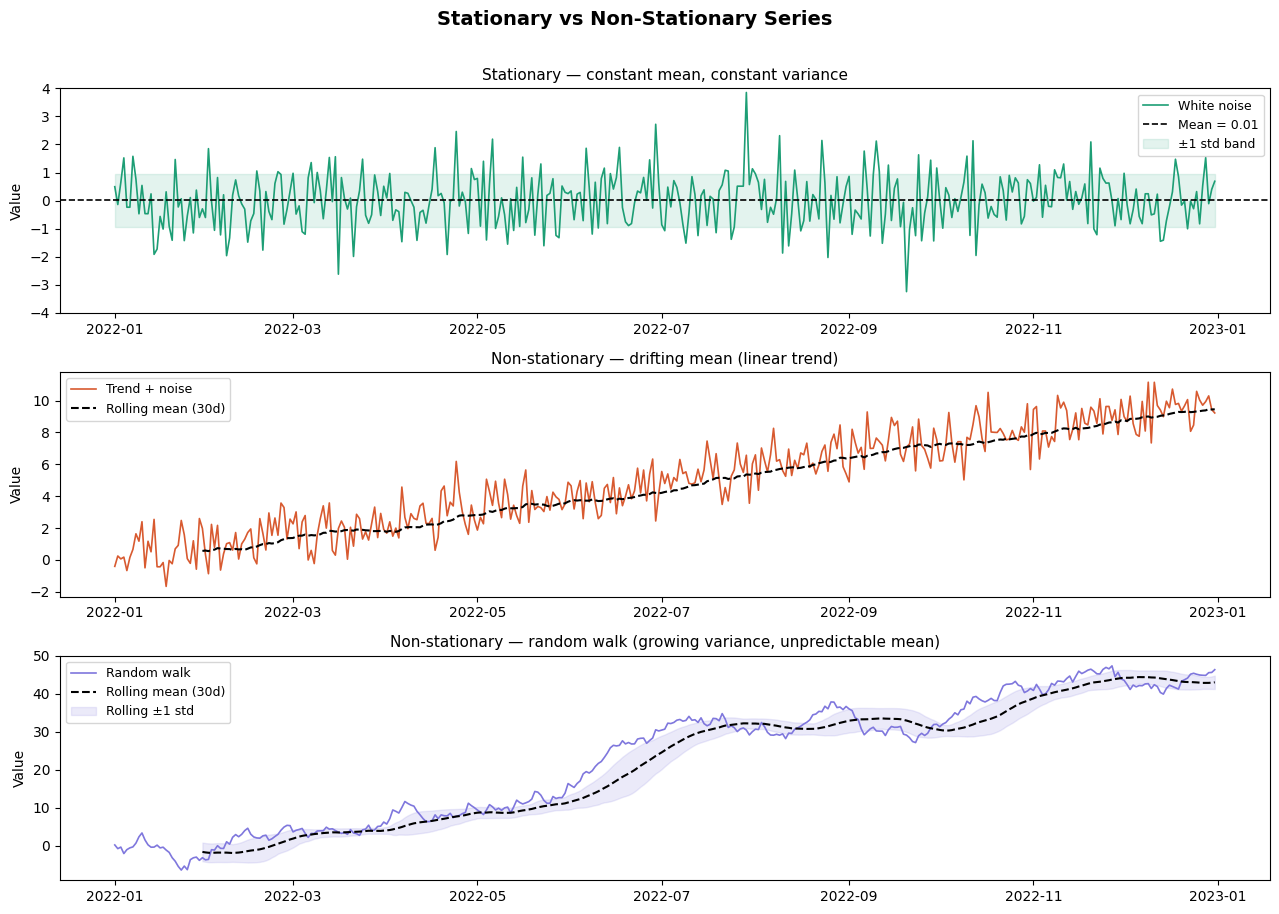

In [95]:
# Plot
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)
fig.suptitle('Stationary vs Non-Stationary Series', fontsize=14, fontweight='bold', y=1.01)

# Panel 1: Stationary (white noise)
axes[0].plot(stationary.index, stationary.values, color='#1D9E75', linewidth=1.2, label='White noise')
axes[0].axhline(y=stationary.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean = {stationary.mean():.2f}')
axes[0].fill_between(stationary.index, stationary.mean() - stationary.std(), stationary.mean() + stationary.std(), alpha=0.12, color='#1D9E75', label='±1 std band')
axes[0].set_title('Stationary — constant mean, constant variance', fontsize=11)
axes[0].set_ylabel('Value')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(-4, 4)

# Panel 2: Non-stationary — trend
axes[1].plot(non_stat_trend.index, non_stat_trend.values, color='#D85A30', linewidth=1.2, label='Trend + noise')
rolling_mean_trend = non_stat_trend.rolling(30).mean()
axes[1].plot(non_stat_trend.index, rolling_mean_trend, color='black', linestyle='--', linewidth=1.5, label='Rolling mean (30d)')
axes[1].set_title('Non-stationary — drifting mean (linear trend)', fontsize=11)
axes[1].set_ylabel('Value')
axes[1].legend(loc='upper left', fontsize=9)

# Panel 3: Non-stationary — random walk
axes[2].plot(random_walk.index, random_walk.values, color='#7F77DD', linewidth=1.2, label='Random walk')
rolling_mean_rw = random_walk.rolling(30).mean()
rolling_std_rw  = random_walk.rolling(30).std()
axes[2].plot(random_walk.index, rolling_mean_rw, color='black', linestyle='--', linewidth=1.5, label='Rolling mean (30d)')
axes[2].fill_between(random_walk.index, rolling_mean_rw - rolling_std_rw, rolling_mean_rw + rolling_std_rw, alpha=0.15, color='#7F77DD', label='Rolling ±1 std')
axes[2].set_title('Non-stationary — random walk (growing variance, unpredictable mean)', fontsize=11)
axes[2].set_ylabel('Value')
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('stationarity_series.png', dpi=150, bbox_inches='tight')
plt.show()

# Augmented Dicky-Fuller Test (ADF)

In [96]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{'='*45}")
    print(f"ADF Test: {name}")
    print(f"{'='*45}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Lags used     : {result[2]}")
    print(f"  Critical values:")
    for k, v in result[4].items():
        print(f"    {k}  :  {v:.4f}")
    conclusion = "STATIONARY" if result[1] < 0.05 else "NON-STATIONARY"
    print(f"\n  Conclusion: {conclusion}")

run_adf(stationary,      "Stationary (white noise)")
run_adf(non_stat_trend,  "Non-stationary (trend)")
run_adf(random_walk,     "Non-stationary (random walk)")


ADF Test: Stationary (white noise)
  ADF Statistic : -20.2371
  p-value       : 0.0000
  Lags used     : 0
  Critical values:
    1%  :  -3.4484
    5%  :  -2.8695
    10%  :  -2.5710

  Conclusion: STATIONARY

ADF Test: Non-stationary (trend)
  ADF Statistic : -0.2597
  p-value       : 0.9310
  Lags used     : 12
  Critical values:
    1%  :  -3.4491
    5%  :  -2.8698
    10%  :  -2.5712

  Conclusion: NON-STATIONARY

ADF Test: Non-stationary (random walk)
  ADF Statistic : -0.4500
  p-value       : 0.9014
  Lags used     : 0
  Critical values:
    1%  :  -3.4484
    5%  :  -2.8695
    10%  :  -2.5710

  Conclusion: NON-STATIONARY


# KPSS Test

In [97]:
from statsmodels.tsa.stattools import kpss
import warnings
warnings.filterwarnings('ignore')   # KPSS raises a harmless truncation warning

def run_kpss(series, name):
    stat, p_value, lags, crits = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n{'='*45}")
    print(f"KPSS Test: {name}")
    print(f"{'='*45}")
    print(f"  KPSS Statistic : {stat:.4f}")
    print(f"  p-value        : {p_value:.4f}")
    print(f"  Lags used      : {lags}")
    print(f"  Critical values:")
    for k, v in crits.items():
        print(f"    {k}  :  {v:.4f}")
    conclusion = "NON-STATIONARY" if p_value < 0.05 else "STATIONARY"
    print(f"\n  Conclusion: {conclusion}")

run_kpss(stationary,      "Stationary (white noise)")
run_kpss(non_stat_trend,  "Non-stationary (trend)")
run_kpss(random_walk,     "Non-stationary (random walk)")


KPSS Test: Stationary (white noise)
  KPSS Statistic : 0.1911
  p-value        : 0.1000
  Lags used      : 0
  Critical values:
    10%  :  0.3470
    5%  :  0.4630
    2.5%  :  0.5740
    1%  :  0.7390

  Conclusion: STATIONARY

KPSS Test: Non-stationary (trend)
  KPSS Statistic : 3.1320
  p-value        : 0.0100
  Lags used      : 11
  Critical values:
    10%  :  0.3470
    5%  :  0.4630
    2.5%  :  0.5740
    1%  :  0.7390

  Conclusion: NON-STATIONARY

KPSS Test: Non-stationary (random walk)
  KPSS Statistic : 3.0118
  p-value        : 0.0100
  Lags used      : 11
  Critical values:
    10%  :  0.3470
    5%  :  0.4630
    2.5%  :  0.5740
    1%  :  0.7390

  Conclusion: NON-STATIONARY


# How to fix non-stationary

## Differencing (Fixes trend)

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [99]:
np.random.seed(42)
n = 365

In [100]:
non_stat_trend = pd.Series(np.linspace(0, 10, n) + np.random.normal(0, 1, n), index=pd.date_range('2022-01-01', periods=n, freq='D'))
non_stat_trend.head()

2022-01-01    0.496714
2022-01-02   -0.110792
2022-01-03    0.702634
2022-01-04    1.605447
2022-01-05   -0.124263
Freq: D, dtype: float64

In [101]:
# Apply first order differencing
differenced = non_stat_trend.diff().dropna()

In [102]:
# Check if it worked
result_before = adfuller(non_stat_trend)
result_after  = adfuller(differenced)

In [103]:
result_before

(np.float64(-0.14191425768186838),
 np.float64(0.9451003530143997),
 11,
 353,
 {'1%': np.float64(-3.4490114443793214),
  '5%': np.float64(-2.8697627072503757),
  '10%': np.float64(-2.5711506161673716)},
 np.float64(986.6771278328105))

In [104]:
result_after

(np.float64(-9.63950443229485),
 np.float64(1.5343411116858907e-16),
 10,
 353,
 {'1%': np.float64(-3.4490114443793214),
  '5%': np.float64(-2.8697627072503757),
  '10%': np.float64(-2.5711506161673716)},
 np.float64(982.6790796151627))

In [105]:
print(f"Before differencing — p-value: {result_before[1]:.4f}")
print(f"After differencing  — p-value: {result_after[1]:.4f}")

Before differencing — p-value: 0.9451
After differencing  — p-value: 0.0000


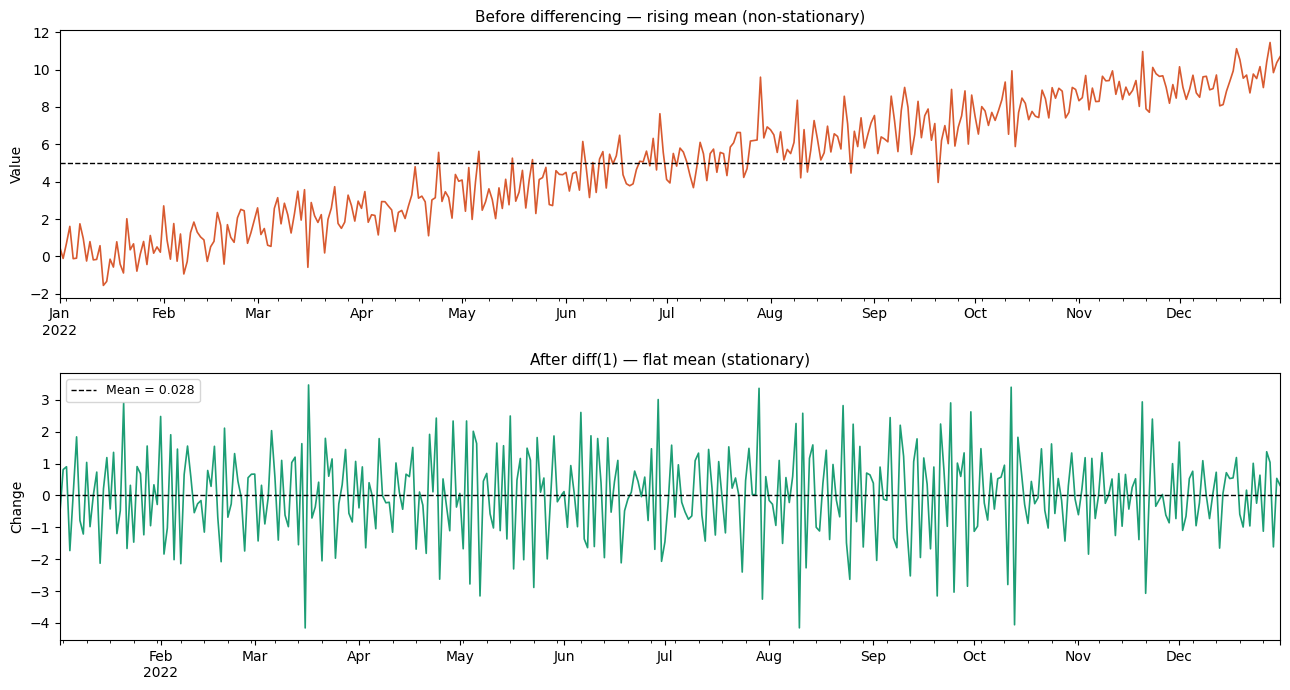

In [106]:
# Plot before and after
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

non_stat_trend.plot(ax=axes[0], color='#D85A30', linewidth=1.2)
axes[0].axhline(non_stat_trend.mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Before differencing — rising mean (non-stationary)', fontsize=11)
axes[0].set_ylabel('Value')

differenced.plot(ax=axes[1], color='#1D9E75', linewidth=1.2)
axes[1].axhline(differenced.mean(), color='black', linestyle='--', linewidth=1,
                label=f'Mean = {differenced.mean():.3f}')
axes[1].set_title('After diff(1) — flat mean (stationary)', fontsize=11)
axes[1].set_ylabel('Change')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fix_differencing.png', dpi=150, bbox_inches='tight')
plt.show()

## Log Transform (stabilizes variance)

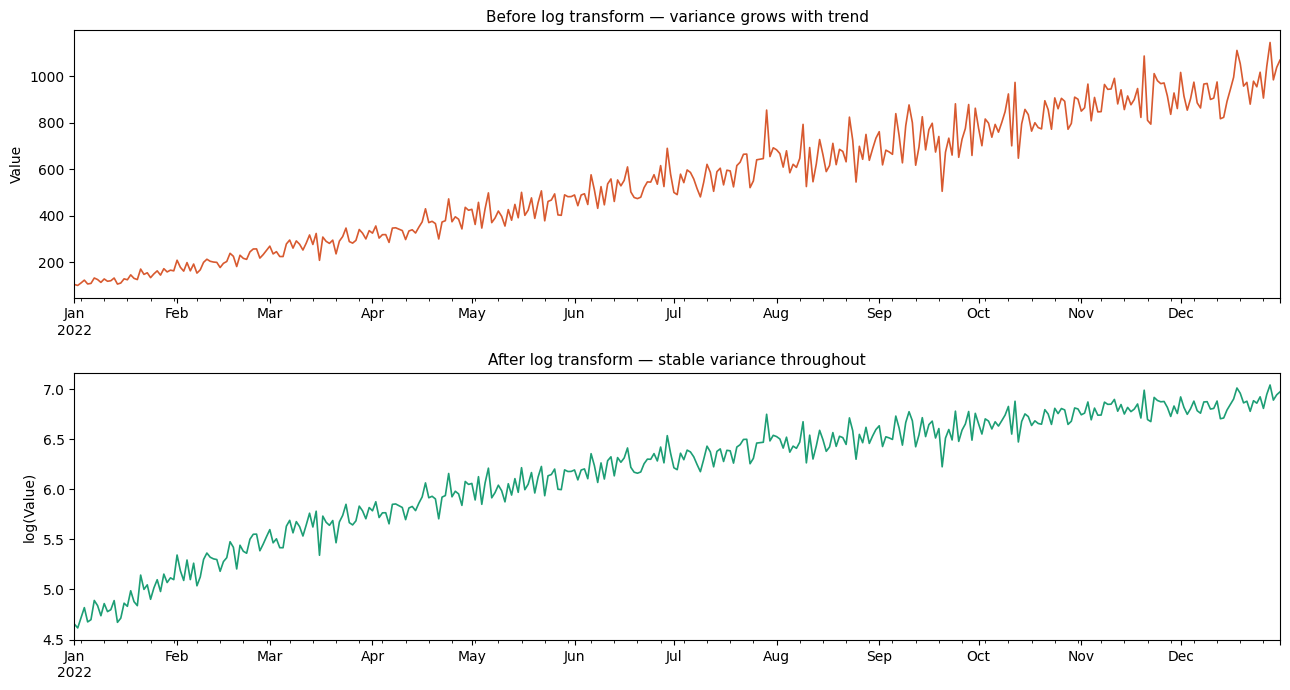

In [107]:
np.random.seed(42)
n = 365

# Multiplicative series — variance grows with level
trend     = np.linspace(100, 1000, n)
noise     = np.random.normal(0, 1, n)
mult_series = pd.Series(trend * (1 + 0.1 * noise), index=pd.date_range('2022-01-01', periods=n, freq='D'))

# Apply log transform
log_series = np.log(mult_series)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

mult_series.plot(ax=axes[0], color='#D85A30', linewidth=1.2)
axes[0].set_title('Before log transform — variance grows with trend', fontsize=11)
axes[0].set_ylabel('Value')

log_series.plot(ax=axes[1], color='#1D9E75', linewidth=1.2)
axes[1].set_title('After log transform — stable variance throughout', fontsize=11)
axes[1].set_ylabel('log(Value)')

plt.tight_layout()
plt.savefig('fix_log.png', dpi=150, bbox_inches='tight')
plt.show()

## Seasonal Differencing

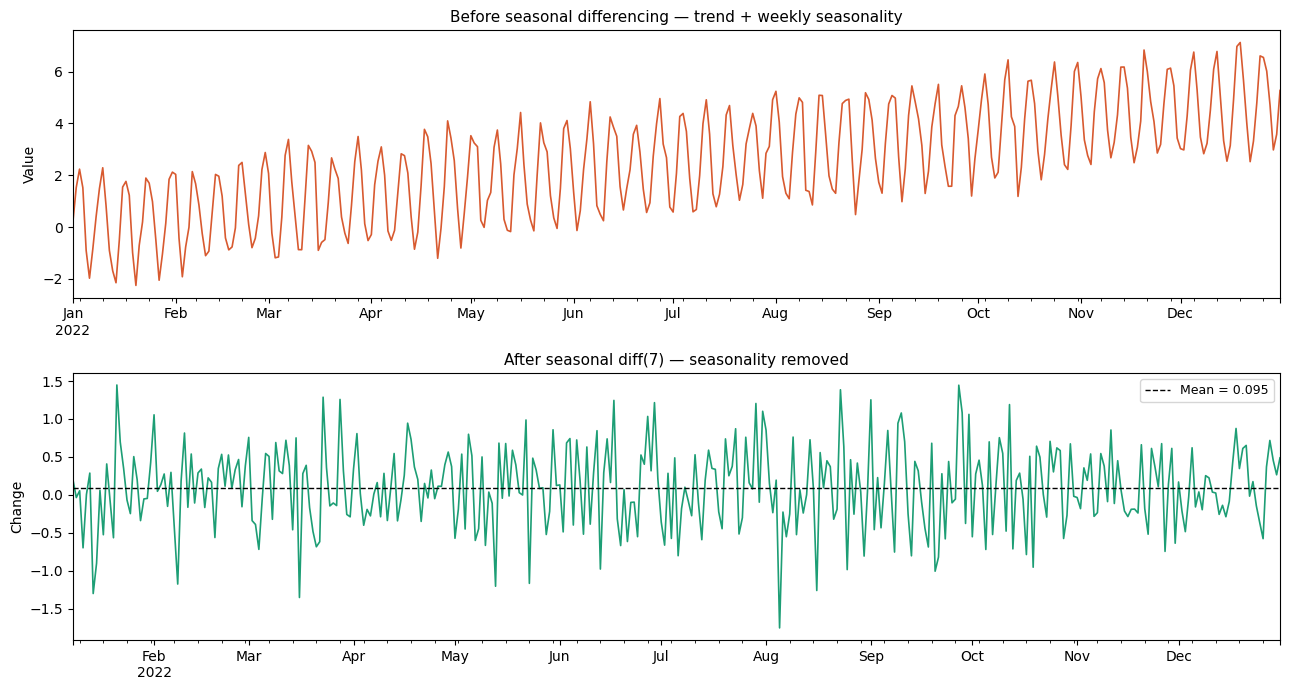

In [108]:
np.random.seed(42)
n = 365

# Series with weekly seasonality + trend
trend     = np.linspace(0, 5, n)
weekly    = 2 * np.sin(2 * np.pi * np.arange(n) / 7)
noise     = np.random.normal(0, 0.4, n)
seasonal_series = pd.Series(trend + weekly + noise,index=pd.date_range('2022-01-01', periods=n, freq='D'))

# Seasonal differencing — subtract value from 7 days ago
seasonal_diff = seasonal_series.diff(7).dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)

seasonal_series.plot(ax=axes[0], color='#D85A30', linewidth=1.2)
axes[0].set_title('Before seasonal differencing — trend + weekly seasonality', fontsize=11)
axes[0].set_ylabel('Value')

seasonal_diff.plot(ax=axes[1], color='#1D9E75', linewidth=1.2)
axes[1].axhline(seasonal_diff.mean(), color='black', linestyle='--',
                linewidth=1, label=f'Mean = {seasonal_diff.mean():.3f}')
axes[1].set_title('After seasonal diff(7) — seasonality removed', fontsize=11)
axes[1].set_ylabel('Change')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fix_seasonal_diff.png', dpi=150, bbox_inches='tight')
plt.show()